In [1]:
import ann_visualizer
import copy
import datetime
from IPython.display import display, Image
import json
import logging
import matplotlib.pyplot as plt
import numpy
import os
import pandas
import pdb
import pickle
import plotly
import pyarrow.parquet as pq
import random
import requests
import six
import slack
import tensorflow as tf
import time

import CS230

plotly.offline.init_notebook_mode(connected=True)
#tf.enable_eager_execution()

# model 6: LSTM

In [2]:
MODEL_NAME = 'model-6'
MODEL_DIR = os.path.join('models', MODEL_NAME)
RESULTS_FILE_PATH = os.path.join(MODEL_DIR, 'results.csv')
EPOCHS = 200
SLACK_WEBHOOK_URL = os.environ['SLACK_WEBHOOK_URL']

logger = CS230.common.get_logger()

In [3]:
#TODO upload image to training error

def slack_post(text, image=None):
    data = {
        'text': datetime.datetime.now().strftime("%H:%M:%S ") + text,
        'username': 'training',
        'icon_emoji': ':robot_face:'
    }
    
    response = requests.post(SLACK_WEBHOOK_URL, data=json.dumps(data), headers={'Content-Type': 'application/json'})
    print('Response: ' + str(response.text))
    print('Response code: ' + str(response.status_code))

# load and format data

In [4]:
FILE_PATHS = []

for dir_path, dir_names, file_names in os.walk(CS230.data.DATA_DIR):
    if dir_path.startswith('.'):
        continue
    
    for file_name in file_names:
        if file_name.endswith('.parquet'):
            file_path = os.path.join(dir_path, file_name)
            FILE_PATHS.append(file_path)
    
    if FILE_PATHS:
        break  # exit after loading files from 1 directory

FILE_PATHS.sort()
FILE_PATHS

['/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_01_01_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_01_02_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_02_01_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_03_01_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_03_02_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_03_03_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_04_01_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140222_01_01_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140222

In [5]:
COLS_X = {
    'x1': ['axCG', 'ayCG', 'azCG', 'brake', 'chassisAccelFL', 'chassisAccelFR', 'chassisAccelRL', 'chassisAccelRR', 
          'clutch', 'handwheelAngle', 'deflectionFL', 'deflectionFR',
          'horizontalSpeed', 'pitchAngle', 'pitchRate', 'rollAngle', 'rollRate', 'throttle', 'vxCG', 'vyCG', 'vzCG', 
          'wheelAccelFL', 'wheelAccelFR', 'wheelAccelRL', 'wheelAccelRR', 'yawAngle', 'yawRate'],
    'x2': ['brake', 'clutch', 'handwheelAngle', 'horizontalSpeed', 'pitchAngle', 'pitchRate', 'rollAngle', 'rollRate',
            'throttle', 'vxCG', 'vyCG', 'vzCG', 'yawAngle', 'yawRate'],
}

COLS_Y = {
    'y1': ['axCG', 'ayCG', 'azCG', 'chassisAccelFL', 'chassisAccelFR', 'chassisAccelRL', 'chassisAccelRR',
          'horizontalSpeed', 'pitchAngle', 'pitchRate', 'rollAngle', 'rollRate', 'vxCG', 'vyCG', 'vzCG',
          'wheelAccelFL', 'wheelAccelFR', 'wheelAccelRL', 'wheelAccelRR', 'yawAngle', 'yawRate'],
    'y2': ['pitchAngle', 'rollAngle', 'vxCG', 'vyCG', 'vzCG',
          'wheelAccelFL', 'wheelAccelFR', 'wheelAccelRL', 'wheelAccelRR', 'yawAngle'],
}

In [6]:
def get_df_x(file_path, cols):
    df = CS230.data.load(file_path)
    df = CS230.data.stride_rows(df, stride=10)
    df.dropna(axis=0, inplace=True)
    df = df.iloc[:-1].reset_index(drop=True)
    return df[cols]

In [7]:
def get_df_y(file_path, cols):
    df = CS230.data.load(file_path)
    df = CS230.data.stride_rows(df, stride=10)
    df.dropna(axis=0, inplace=True)
    df = df.iloc[1:].reset_index(drop=True)
    return df[cols]

In [8]:
def get_tensor_x(df):
    x = numpy.reshape(df.values, (df.shape[0], 1, df.shape[1]))
    x = tf.cast(x, tf.float64)
    return x

In [9]:
def get_tensor_y(df):
    y = tf.cast(df.values, tf.float64)
    return y

# get data

In [10]:
data_name = 'train'

In [11]:
def get_data(cols_x, cols_y, sequence_length):
    DATA = {}
    DATA[data_name] = {
        'df': {
            'x': pandas.DataFrame(columns=COLS_X[cols_x]),
            'y': pandas.DataFrame(columns=COLS_Y[cols_y])
        }
    }

    for i in range(2):
        file_path = FILE_PATHS[i]

        df_x = get_df_x(file_path, cols=COLS_X[cols_x])
        DATA[data_name]['df']['x'] = pandas.concat([
            DATA[data_name]['df']['x'],
            df_x
        ], ignore_index=True, sort=False)

        df_y = get_df_y(file_path, cols=COLS_Y[cols_y])
        DATA[data_name]['df']['y'] = pandas.concat([
            DATA[data_name]['df']['y'], 
            df_y
        ], ignore_index=True, sort=False)

    DATA[data_name]['generator'] = tf.keras.preprocessing.sequence.TimeseriesGenerator(
                                    DATA[data_name]['df']['x'].values,
                                    DATA[data_name]['df']['y'].values,
                                    length=sequence_length, sampling_rate=1  #, shuffle=True
    )
    
    return DATA

# build models

09-45-27 | INFO | models/model-6/20190603094527
INFO:CS230:models/model-6/20190603094527
09-45-27 | INFO | {'seq_len': 10, 'cols_x': 'x1', 'cols_y': 'y1', 'learning_rate': 0.02, 'learning_rate_decay': 0.0, 'dropout': 0.0, 'time_distributed': False, 'batch_norm': True}
INFO:CS230:{'seq_len': 10, 'cols_x': 'x1', 'cols_y': 'y1', 'learning_rate': 0.02, 'learning_rate_decay': 0.0, 'dropout': 0.0, 'time_distributed': False, 'batch_norm': True}


Response: ok
Response code: 200
Instructions for updating:
Colocations handled automatically by placer.


Instructions for updating:
Colocations handled automatically by placer.


_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 10, 27)            5940      
_________________________________________________________________
batch_normalization_v1 (Batc (None, 10, 27)            108       
_________________________________________________________________
lstm_1 (LSTM)                (None, 27)                5940      
_________________________________________________________________
dense (Dense)                (None, 21)                588       
Total params: 12,576
Trainable params: 12,522
Non-trainable params: 54
_________________________________________________________________


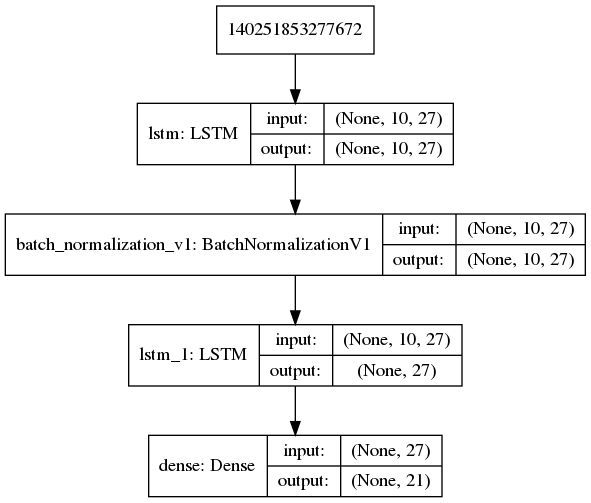

Instructions for updating:
Use tf.cast instead.


Instructions for updating:
Use tf.cast instead.


Instructions for updating:
Use tf.cast instead.


Instructions for updating:
Use tf.cast instead.


Epoch 1/200
1001/1002 [============================>.] - ETA: 0s - loss: 256.5273 - mean_absolute_error: 4.5579
Epoch 00001: loss improved from inf to 256.46761, saving model to models/model-6/20190603094527/epoch1.h5
1002/1002 [==============================] - 18s 18ms/step - loss: 256.3413 - mean_absolute_error: 4.5581
Epoch 2/200
 999/1002 [============================>.] - ETA: 0s - loss: 116.6379 - mean_absolute_error: 3.7286
Epoch 00002: loss improved from 256.46761 to 116.44402, saving model to models/model-6/20190603094527/epoch2.h5
1002/1002 [==============================] - 17s 17ms/step - loss: 116.3993 - mean_absolute_error: 3.7264
Epoch 3/200
1001/1002 [============================>.] - ETA: 0s - loss: 134.5770 - mean_absolute_error: 3.8104
Epoch 00003: loss did not improve from 116.44402
1002/1002 [==============================] - 17s 17ms/step - loss: 134.9116 - mean_absolute_error: 3.8148
Epoch 4/200
 423/1002 [===========>..................] - ETA: 10s - loss: 93.37

In [ ]:
DATA = None
best_params = {
    'mean_absolute_error': 1000,
}
if os.path.exists(RESULTS_FILE_PATH):
    df_results = pandas.read_csv(RESULTS_FILE_PATH)
else:
    df_results = pandas.DataFrame()

for sequence_length in range(10, 100, 10):
    for cols_x in ['x1', 'x2']:
        for cols_y in ['y1', 'y2']:
            
            del DATA
            DATA = get_data(cols_x, cols_y, sequence_length)
            
            for learning_rate in [2e-2, 1e-2, 1e-3]:
                for learning_rate_decay in [0, 1e-6]:
                    for dropout in [0, 0.1]:
                        for time_distributed in [True, False]:
                            for batch_norm in [False, True]:
                                try:
                                    dt_start = datetime.datetime.now()

                                    SESS_DATE_TIME = datetime.datetime.now().strftime("%Y%m%d%H%M%S")
                                    SESS_DIR = os.path.join(MODEL_DIR, SESS_DATE_TIME)
                                    params = {
                                        'seq_len': int(sequence_length),
                                        'cols_x': cols_x,
                                        'cols_y': cols_y,
                                        'learning_rate': float(learning_rate),
                                        'learning_rate_decay': float(learning_rate_decay),
                                        'dropout': float(dropout),
                                        'time_distributed': time_distributed,
                                        'batch_norm': batch_norm,
                                    }

                                    # check if already tried these params
                                    isin_map = {}
                                    keys = []
                                    for key, val in six.iteritems(params):
                                        isin_map[key] = [val]
                                        keys.append(key)

                                    if not df_results.empty and (True in df_results[keys].isin(isin_map).all(axis=1).values):
                                        logging.warning('skipping, already in results: %s', params)
                                        continue

                                    for dir_path in [MODEL_DIR, SESS_DIR]:
                                        if not os.path.isdir(dir_path):
                                            os.mkdir(dir_path)
                                    with open(os.path.join(SESS_DIR, 'params.json'), 'w') as f:
                                        json.dump(params, f)

                                    logger.info(SESS_DIR)
                                    logger.info(params)
                                    slack_post(text='`%s` params : %s' % (SESS_DIR, params))

                                    m = DATA[data_name]['df']['x'].shape[0]
                                    n_x = DATA[data_name]['df']['x'].shape[1]
                                    n_y = DATA[data_name]['df']['y'].shape[1]

                                    # build model
                                    model = tf.keras.Sequential()

                                    model.add(tf.keras.layers.LSTM(n_x, return_sequences=True, dropout=dropout, 
                                                                   recurrent_dropout=dropout, input_shape=(sequence_length, n_x)))

                                    if batch_norm:
                                        model.add(tf.keras.layers.BatchNormalization())

                                    if time_distributed:
                                        model.add(tf.keras.layers.TimeDistributed(
                                            tf.keras.layers.Dense(n_x, activation='sigmoid')))

                                    model.add(tf.keras.layers.LSTM(n_x, dropout=dropout, recurrent_dropout=dropout))

                                    #model.add(tf.keras.layers.BatchNormalization())
                                    #model.add(tf.keras.layers.Dropout(0.1))
                                    model.add(tf.keras.layers.Dense(n_y, activation='linear'))

                                    # summarize model
                                    model.summary()

                                    # visualize model
                                    file_path = os.path.join(SESS_DIR, 'architecture.png')
                                    tf.keras.utils.plot_model(model, file_path, show_shapes=True, show_layer_names=True)
                                    display(Image(filename=file_path))

                                    # set optimizer
                                    #optimizer = tf.train.AdamOptimizer(0.01)
                                    optimizer = tf.keras.optimizers.Adam(lr=learning_rate, decay=learning_rate_decay)
                                    #optimizer = tf.keras.optimizers.SGD(lr=0.03, decay=1e-6, momentum=0.9, nesterov=True)

                                    # compile model
                                    model.compile(
                                        optimizer=optimizer, 
                                        loss='mean_squared_error', 
                                        metrics=['mean_absolute_error']
                                    )

                                    # set callbacks
                                    file_path = os.path.join(SESS_DIR, 'epoch{epoch}.h5')
                                    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(file_path, monitor='loss', 
                                                        verbose=1, save_weights_only=True, save_best_only=True, mode='min')
                                    stop_callback = tf.keras.callbacks.EarlyStopping(
                                                        monitor='loss', min_delta=1e-2, patience=5, verbose=1)
                                    callbacks = [checkpoint_callback, stop_callback]

                                    # train model
                                    history = model.fit_generator(
                                        DATA['train']['generator'], 
                                        epochs=EPOCHS, 
                                        steps_per_epoch=len(DATA['train']['generator']), 
                                        callbacks=callbacks
                                    )

                                    # save model
                                    file_name = 'model_end_%s.h5' % history.history['mean_absolute_error'][-1]
                                    model.save(os.path.join(SESS_DIR, file_name))

                                    # save time
                                    dt_delta = datetime.datetime.now() - dt_start
                                    total_time = '%s:%s' % (int(dt_delta.total_seconds() / 60), round(dt_delta.total_seconds() % 60))

                                    # save results 
                                    params['loss'] = float(history.history['loss'][-1])
                                    params['mean_absolute_error'] = float(history.history['mean_absolute_error'][-1])
                                    params['session'] = SESS_DIR
                                    params['time'] = total_time
                                    if df_results.empty:
                                        df_results = pandas.DataFrame([params])
                                    else:
                                        df_results = pandas.concat([df_results, pandas.DataFrame([params])], 
                                                                   ignore_index=True, sort=False)
                                    df_results.to_csv(RESULTS_FILE_PATH)

                                    # post result to slack
                                    slack_post(text='`%s` time : `%s`, error : *%s*, loss: *%s*' % (SESS_DIR, total_time,
                                           history.history['mean_absolute_error'][-1], history.history['loss'][-1]))

                                    # save best params
                                    if history.history['mean_absolute_error'][-1] < best_params['mean_absolute_error']:
                                        best_params = copy.deepcopy(params)

                                        slack_post(text='`%s` :bananadance: best' % (SESS_DIR))

                                        with open(os.path.join(MODEL_DIR, 'best_params.json'), 'w') as f:
                                            json.dump(best_params, f)
                                    
                                    # post results overview to slack
                                    slack_post(text='```%s```' % df_results)

                                    # plot error
                                    file_path = os.path.join(SESS_DIR, 'training_error.jpeg')
                                    title = 'Model 6: training mean absolute error: %s<br>%s' % (
                                        history.history['mean_absolute_error'][-1],
                                        params
                                    )
                                    trace = plotly.graph_objs.Scatter(
                                        x=list(range(1, len(pandas.DataFrame(history.history['mean_absolute_error']))+1)),
                                        y=history.history['mean_absolute_error']
                                    )
                                    layout = plotly.graph_objs.Layout(
                                        title=title,
                                        xaxis=dict(title='epochs'),
                                        yaxis=dict(title='mean absolute error')
                                    )
                                    fig = plotly.graph_objs.Figure(data=[trace], layout=layout)

                                    # save plot to file
                                    CS230.data.write_image(fig, file_path)

                                    # display plot from file
                                    display(Image(filename=file_path))

                                    logging.info('best params: %s', best_params)

                                except Exception as e:
                                    logger.exception(e)
                                    slack_post(text=':facepalm: `%s`' % str(e))

                                del model
                                del params
                                del history